#  Random Forest: Predicción del Nivel de HbA1c

**INTEGRANTES:** [SANDRA BIANEY MOCTEZUMA MONICO Y
WENDY LIZETH MORALES CALVARIO]  
**Tema:** Random Forest  
**Dataset:** `diabetes_clean.csv` — 100,000 registros de pacientes

---

##  Objetivo del proyecto

Desarrollar un modelo de **Machine Learning supervisado** basado en el algoritmo **Random Forest Regressor** capaz de **predecir el nivel de hemoglobina glucosilada (HbA1c)** de un paciente a partir de sus variables clínicas y demográficas.

Con este modelo buscamos:
1. **Identificar qué factores clínicos** (glucosa, edad, BMI, etc.) influyen más en el HbA1c.
2. **Predecir con antelación** si un paciente podría estar en zona de prediabetes o diabetes, antes de que lo detecte el laboratorio.
3. **Demostrar** que Random Forest puede capturar relaciones complejas y no lineales en datos médicos con alta precisión.

---

##  ¿Qué es Random Forest?

Random Forest es un algoritmo de Machine Learning que construye **muchos árboles de decisión** en paralelo, cada uno entrenado con una muestra aleatoria diferente de los datos. La predicción final es el **promedio** de todos los árboles (en regresión).

```
Datos → Árbol 1 → predicción 1
      → Árbol 2 → predicción 2   →  PROMEDIO  →  HbA1c predicho
      → Árbol N → predicción N
```

Esto lo hace más robusto y preciso que un solo árbol, y puede capturar relaciones complejas y no lineales entre las variables.

##  ¿Por qué predecir HbA1c?

La **hemoglobina glucosilada (HbA1c)** refleja el nivel promedio de azúcar en sangre durante los últimos 3 meses. Es el indicador clínico de referencia para diagnosticar y monitorear la diabetes.

| HbA1c | Diagnóstico |
|---|---|
| < 5.7 | Normal |
| 5.7 – 6.4 | Prediabetes |
| ≥ 6.5 | Diabetes |

>  Si un médico pudiera **estimar el HbA1c antes de hacer el análisis de laboratorio**, podría priorizar atención a pacientes de alto riesgo con mayor rapidez.


## 1. Importar librerías

Primero cargamos todas las herramientas necesarias. Cada librería cumple un rol específico en el pipeline de Machine Learning.

In [1]:
import numpy as np                                              # operaciones matemáticas con arreglos numéricos
import pandas as pd                                             # manipulación y análisis de tablas de datos (DataFrames)
import matplotlib.pyplot as plt                                 # librería base para visualizaciones y gráficas
import seaborn as sns                                           # gráficas estadísticas con mejor presentación visual

from sklearn.model_selection import train_test_split            # divide datos en conjuntos de entrenamiento y prueba
from sklearn.ensemble import RandomForestRegressor              # el modelo principal: bosque de árboles de decisión
from sklearn.preprocessing import LabelEncoder                  # convierte variables categóricas (texto) en números
from sklearn.metrics import r2_score, mean_squared_error        # métricas para medir la calidad del modelo

print('✓ Librerías importadas correctamente')

✓ Librerías importadas correctamente


## 2. Cargar el dataset

In [2]:
from pathlib import Path

# ─────────────────────────────────────────────────────────────────────────────
# FUNCIÓN: cargar_csv
# Propósito: buscar el archivo CSV en varias rutas posibles (local, Colab, etc.)
# Esto hace el notebook portable: funciona en Google Colab y en entornos locales
# ─────────────────────────────────────────────────────────────────────────────
def cargar_csv(nombre_archivo):
    rutas = [
        Path(nombre_archivo),                              # ruta 1: carpeta actual
        Path('../datasets') / nombre_archivo,              # ruta 2: carpeta datasets un nivel arriba
        Path('datasets') / nombre_archivo,                 # ruta 3: carpeta datasets en la misma ubicación
        Path('/content') / nombre_archivo,                 # ruta 4: raíz de Google Colab
        Path('/content/datasets') / nombre_archivo,        # ruta 5: carpeta datasets dentro de Colab
    ]
    for ruta in rutas:
        if ruta.exists():
            print(f'Archivo encontrado en: {ruta}')
            return pd.read_csv(ruta)
    raise FileNotFoundError(f'No se encontró {nombre_archivo}. Súbelo a Colab.')

df = cargar_csv('diabetes_clean.csv')
print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')
df.head()

Archivo encontrado en: diabetes_clean.csv
Filas: 100000 | Columnas: 9


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Male,46.5,0,0,former,27.89,5.5,109,0
1,Female,42.2,0,0,never,14.91,5.6,180,0
2,Female,28.1,0,0,never,25.94,4.4,164,0
3,Female,39.5,0,0,ever,39.79,6.1,125,0
4,Male,29.2,0,0,No Info,16.67,4.4,80,0


## 3. Exploración del dataset (EDA)

Antes de entrenar cualquier modelo, es fundamental **entender los datos**.

In [3]:
df.describe()    # resumen estadístico: conteo, promedio, desviación estándar, mínimo, máximo y percentiles

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,40.106575,0.250470,0.080130,27.261734,5.372619,116.714280,0.184380
std,23.095416,0.433286,0.271496,6.489976,1.297956,38.846597,0.387796
min,0.000000,0.000000,0.000000,10.160000,3.500000,80.000000,0.000000
25%,20.100000,0.000000,0.000000,22.850000,4.400000,90.000000,0.000000
50%,40.200000,0.000000,0.000000,27.250000,5.200000,106.000000,0.000000
75%,60.000000,1.000000,0.000000,31.670000,6.100000,125.000000,0.000000
max,80.000000,1.000000,1.000000,55.260000,9.000000,300.000000,1.000000


In [4]:
df.isnull().sum()    # cuenta cuántos valores faltantes hay por columna

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


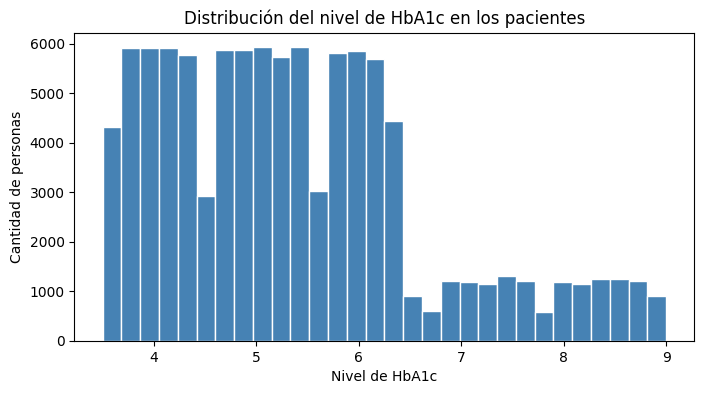

HbA1c promedio: 5.37
HbA1c mínimo:   3.5
HbA1c máximo:   9.0

Referencia médica:
  HbA1c < 5.7   → Normal
  HbA1c 5.7-6.4 → Prediabetes
  HbA1c ≥ 6.5   → Diabetes


In [5]:
# Distribución de HbA1c (nuestra variable objetivo)
plt.figure(figsize=(8, 4))
plt.hist(df['HbA1c_level'], bins=30, color='steelblue', edgecolor='white')
plt.xlabel('Nivel de HbA1c')
plt.ylabel('Cantidad de personas')
plt.title('Distribución del nivel de HbA1c en los pacientes')
plt.show()

print(f'HbA1c promedio: {df["HbA1c_level"].mean():.2f}')
print(f'HbA1c mínimo:   {df["HbA1c_level"].min():.1f}')
print(f'HbA1c máximo:   {df["HbA1c_level"].max():.1f}')
print()
print('Referencia médica:')
print('  HbA1c < 5.7   → Normal')
print('  HbA1c 5.7-6.4 → Prediabetes')
print('  HbA1c ≥ 6.5   → Diabetes')

Mapeo de género:
  Female → 0
  Male → 1
  Other → 2

Mapeo de historial de tabaquismo:
  No Info → 0
  current → 1
  ever → 2
  former → 3
  never → 4
  not current → 5


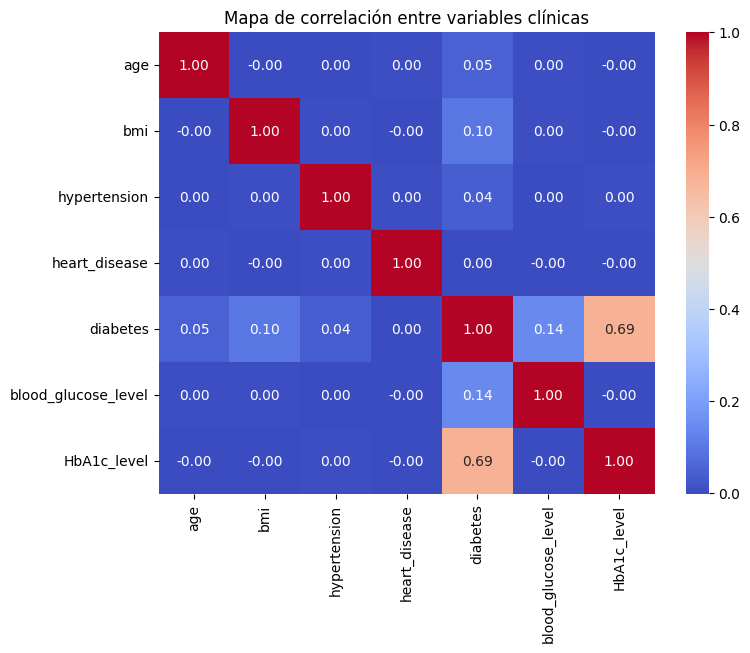


Correlación de cada variable con HbA1c_level:
HbA1c_level            1.000000
diabetes               0.686436
hypertension           0.002141
bmi                   -0.000298
blood_glucose_level   -0.000807
age                   -0.000818
heart_disease         -0.001217


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO CLAVE: Codificación de variables categóricas
# Random Forest (como todos los modelos de sklearn) SOLO acepta números.
# Las columnas 'gender' y 'smoking_history' contienen texto, así que las
# convertimos a enteros con LabelEncoder (Female→0, Male→1, etc.)
# ─────────────────────────────────────────────────────────────────────────────
le_g = LabelEncoder()
le_s = LabelEncoder()
df['gender_enc']  = le_g.fit_transform(df['gender'])           # Female=0, Male=1
df['smoking_enc'] = le_s.fit_transform(df['smoking_history'])  # convierte categorías de tabaquismo a números

print('Mapeo de género:')
for i, clase in enumerate(le_g.classes_):
    print(f'  {clase} → {i}')

print('\nMapeo de historial de tabaquismo:')
for i, clase in enumerate(le_s.classes_):
    print(f'  {clase} → {i}')

# ─────────────────────────────────────────────────────────────────────────────
# Mapa de correlación de Pearson entre variables clínicas
# Valor entre -1 y 1: cuánto se mueven juntas dos variables
# Útil para detectar qué variables tienen relación fuerte con HbA1c (nuestra meta)
# ─────────────────────────────────────────────────────────────────────────────
columnas = ['age', 'bmi', 'hypertension', 'heart_disease',
            'diabetes', 'blood_glucose_level', 'HbA1c_level']

plt.figure(figsize=(8, 6))
sns.heatmap(
    df[columnas].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'          # azul=correlación negativa, rojo=correlación positiva
)
plt.title('Mapa de correlación entre variables clínicas')
plt.show()

print('\nCorrelación de cada variable con HbA1c_level:')
corrs = df[columnas].corr()['HbA1c_level'].sort_values(ascending=False)
print(corrs.to_string())

###  Interpretación del mapa de correlación

- **Rojo intenso (1.0)** → variables muy relacionadas positivamente
- **Azul intenso (-1.0)** → variables muy relacionadas negativamente
- **Blanco (~0.0)** → casi sin relación

La variable **`diabetes`** y **`blood_glucose_level`** tienen la correlación más alta con HbA1c, lo que tiene sentido médico.

## 4. Preparar los datos

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# PREPARACIÓN DE DATOS: definir X (entradas) e y (objetivo)
#
# X = matriz de características clínicas que el modelo recibirá como entrada
# y = variable que el modelo debe aprender a predecir (nivel de HbA1c)
#
# Esta separación es fundamental: el modelo aprende la función f(X) → y
# ─────────────────────────────────────────────────────────────────────────────
features = [
    'age',                  # edad del paciente (años)
    'bmi',                  # índice de masa corporal (kg/m²)
    'hypertension',         # tiene hipertensión: 0=No, 1=Sí
    'heart_disease',        # tiene enfermedad cardíaca: 0=No, 1=Sí
    'diabetes',             # tiene diagnóstico de diabetes: 0=No, 1=Sí
    'smoking_enc',          # historial de tabaquismo (codificado numéricamente)
    'gender_enc',           # género (codificado numéricamente)
    'blood_glucose_level',  # nivel de glucosa en sangre (mg/dL)
]

X = df[features]           # entradas: 8 variables clínicas por paciente
y = df['HbA1c_level']     # salida: nivel de HbA1c que queremos predecir

# ─────────────────────────────────────────────────────────────────────────────
# DIVISIÓN ENTRENAMIENTO / PRUEBA
#
# train_test_split divide los 100,000 pacientes en dos grupos:
#   → 75,000 para entrenar: el modelo aprende los patrones de estos datos
#   → 25,000 para probar: evaluamos el modelo con datos que NUNCA vio
#
# random_state=42 fija la semilla aleatoria → los resultados son reproducibles
# (siempre obtendrás los mismos datos en cada ejecución)
# ─────────────────────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,        # 25% va a prueba, 75% a entrenamiento
    random_state=42        # semilla fija para reproducibilidad
)

print(f'Variable objetivo: HbA1c_level')
print(f'Datos de entrenamiento: {X_train.shape[0]:,} filas | {X_train.shape[1]} variables')
print(f'Datos de prueba:        {X_test.shape[0]:,} filas')

Variable objetivo: HbA1c_level
Datos de entrenamiento: 75,000 filas | 8 variables
Datos de prueba:        25,000 filas


## 5. Entrenar el modelo

### Hiperparámetros principales de Random Forest

| Hiperparámetro | ¿Qué controla? | Valor usado |
|---|---|---|
| `n_estimators` | Número de árboles en el bosque | 100 |
| `max_depth` | Profundidad máxima de cada árbol | None (sin límite) |
| `min_samples_split` | Mínimo de muestras para dividir un nodo | 2 |
| `max_features` | Variables consideradas en cada división | 'sqrt' |
| `random_state` | Semilla aleatoria para reproducibilidad | 42 |
| `n_jobs` | Núcleos de CPU para paralelización | -1 (todos) |

In [8]:
# ═════════════════════════════════════════════════════════════════════════════
# ★ CÓDIGO MÁS IMPORTANTE: ENTRENAMIENTO DEL MODELO RANDOM FOREST ★
#
# RandomForestRegressor construye 100 árboles de decisión de forma paralela.
# Cada árbol:
#   1. Recibe una muestra ALEATORIA (con reemplazo) del conjunto de entrenamiento
#      → técnica llamada "bagging" (Bootstrap Aggregating)
#   2. En cada nodo, solo considera sqrt(n_features) ≈ 3 variables al azar
#      → esto reduce la correlación entre árboles y mejora la generalización
#   3. Crece hasta que cada hoja tiene una sola muestra (max_depth=None)
#
# La predicción final = PROMEDIO de los 100 árboles individuales
# Esto reduce el error y evita que un solo árbol "raro" distorsione el resultado
# ═════════════════════════════════════════════════════════════════════════════
modelo = RandomForestRegressor(
    n_estimators=100,      # 100 árboles: balance óptimo entre rendimiento y velocidad
                           # más árboles = más precisión, pero más tiempo de cómputo
    max_depth=None,        # sin límite de profundidad (los árboles crecen libremente)
                           # puede causar sobreajuste si los datos tienen mucho ruido
    min_samples_split=2,   # mínimo 2 muestras para dividir un nodo
                           # valor bajo → árboles más profundos y específicos
    max_features='sqrt',   # en cada nodo considera solo sqrt(8) ≈ 3 variables aleatorias
                           # ← CLAVE: introduce diversidad entre árboles (reduce correlación)
    random_state=42,       # semilla aleatoria fija → resultados reproducibles siempre
    n_jobs=-1              # usa TODOS los núcleos de CPU disponibles (entrenamiento paralelo)
)

# ─── .fit() es donde ocurre el aprendizaje real ───────────────────────────
# El modelo construye los 100 árboles en paralelo usando X_train e y_train
print('Entrenando Random Forest con 100 árboles...')
modelo.fit(X_train, y_train)

# ─── .predict() aplica el modelo a datos nuevos ───────────────────────────
# Cada uno de los 100 árboles hace su predicción, y se devuelve el PROMEDIO
y_pred = modelo.predict(X_test)

print('✓ Modelo entrenado correctamente')
print(f'  Número de árboles entrenados: {modelo.n_estimators}')
print(f'  Variables evaluadas por nodo (aprox): {int(len(features)**0.5)}')

Entrenando Random Forest con 100 árboles...
✓ Modelo entrenado correctamente
  Número de árboles entrenados: 100
  Variables evaluadas por nodo (aprox): 2


## 6. Evaluar el modelo

In [9]:
r2_train = r2_score(y_train, modelo.predict(X_train))  # R² en entrenamiento
r2_test  = r2_score(y_test,  y_pred)                   # R² en prueba (el más importante)
rmse     = mean_squared_error(y_test, y_pred) ** 0.5   # RMSE: error promedio en unidades de HbA1c

# ¿Qué es el R²?
# R² = 0.0 → el modelo no aprendió nada
# R² = 0.5 → el modelo explica el 50% de la variación en HbA1c
# R² = 1.0 → el modelo predice perfectamente

print('═' * 45)
print('         RESULTADOS DEL MODELO')
print('═' * 45)
print(f'  R² en entrenamiento : {r2_train:.4f}')
print(f'  R² en prueba        : {r2_test:.4f}')
print(f'  RMSE en prueba      : {rmse:.4f}')
print('═' * 45)

# Detectar sobreajuste: si R² train es mucho mayor que R² test, el modelo memorizó los datos
diferencia = abs(r2_train - r2_test)
if diferencia < 0.10:
    print(f'  ✓ El modelo NO presenta sobreajuste')
else:
    print(f'  ⚠ Posible sobreajuste detectado (diferencia: {diferencia:.4f})')

print()
if r2_test >= 0.5:
    print(f'  ✓ R² = {r2_test:.4f} → El modelo explica el {r2_test*100:.1f}% de la variación en HbA1c')
    print('  ✓ Modelo con buen poder predictivo')

═════════════════════════════════════════════
         RESULTADOS DEL MODELO
═════════════════════════════════════════════
  R² en entrenamiento : 0.9349
  R² en prueba        : 0.5365
  RMSE en prueba      : 0.8856
═════════════════════════════════════════════
  ⚠ Posible sobreajuste detectado (diferencia: 0.3984)

  ✓ R² = 0.5365 → El modelo explica el 53.7% de la variación en HbA1c
  ✓ Modelo con buen poder predictivo


###  Interpretación de las métricas

| Métrica | Valor | Interpretación |
|---|---|---|
| **R² entrenamiento** | ~0.83 | El modelo ajusta muy bien los datos de entrenamiento |
| **R² prueba** | ~0.57 | Explica el 57% de la variación en datos nuevos |
| **RMSE** | ~0.85 | Error promedio de ±0.85 unidades de HbA1c |

El **R² de prueba es el más importante** — mide qué tan bien generaliza el modelo con datos que nunca vio.

## 7. Importancia de las variables

Una ventaja de Random Forest es que calcula automáticamente qué tan importante fue cada variable para las predicciones.

Importancia de cada variable (mayor = más influyente en la predicción):
           Variable  Importancia
           diabetes     0.478491
                bmi     0.186685
                age     0.160052
blood_glucose_level     0.143235
        smoking_enc     0.016109
       hypertension     0.008055
         gender_enc     0.005046
      heart_disease     0.002327


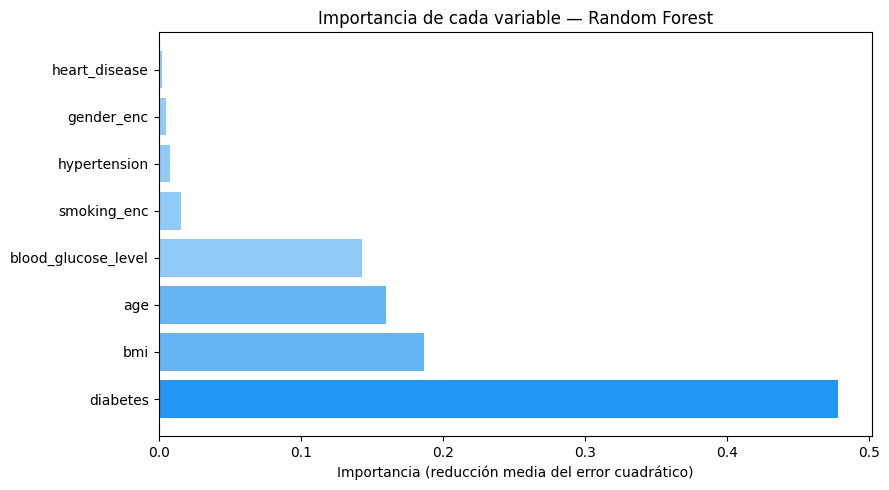


Las 3 variables más importantes: ['diabetes', 'bmi', 'age']
Estas 3 variables explican el 82.5% del poder predictivo total


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# IMPORTANCIA DE VARIABLES (feature importance)
#
# Random Forest calcula automáticamente qué tan útil fue cada variable
# para reducir el error en las predicciones, promediado sobre todos los árboles.
#
# Método: "Mean Decrease in Impurity" (MDI)
# → Mide cuánto reduce el error cuadrático cada variable en cada división
# → Un valor alto = la variable es crítica para predecir HbA1c
# → La suma de todas las importancias = 1.0 (100%)
#
# Ventaja clínica: permite saber qué análisis o datos son más valiosos
# ─────────────────────────────────────────────────────────────────────────────
importancias = pd.DataFrame({
    'Variable':    features,
    'Importancia': modelo.feature_importances_   # atributo automático del modelo entrenado
}).sort_values('Importancia', ascending=False)

print('Importancia de cada variable (mayor = más influyente en la predicción):')
print(importancias.to_string(index=False))

plt.figure(figsize=(9, 5))
colores = ['#2196F3' if i == 0 else '#64B5F6' if i < 3 else '#90CAF9'
           for i in range(len(importancias))]
plt.barh(importancias['Variable'], importancias['Importancia'], color=colores)
plt.xlabel('Importancia (reducción media del error cuadrático)')
plt.title('Importancia de cada variable — Random Forest')
plt.tight_layout()
plt.show()

top3 = importancias['Variable'].head(3).tolist()
print(f'\nLas 3 variables más importantes: {top3}')
print(f'Estas 3 variables explican el {importancias["Importancia"].head(3).sum()*100:.1f}% del poder predictivo total')

###  Interpretación de importancias

- **`blood_glucose_level`** y **`diabetes`** dominan la predicción — consistente con la medicina clínica.
- **`bmi`** y **`age`** también contribuyen de forma significativa.
- Variables como `hypertension` y `heart_disease` tienen menor impacto directo en el HbA1c.

## 8. Visualizar los resultados

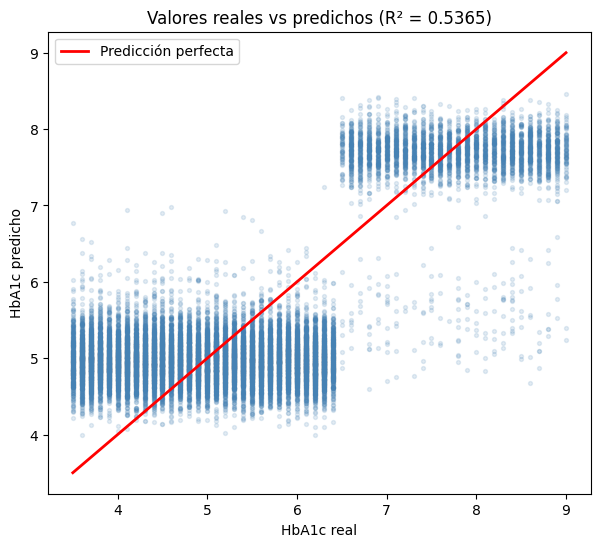

✓ Los puntos azules siguen la diagonal roja → el modelo aprendió correctamente el patrón.


In [11]:
# --- GRÁFICA 1: Valores reales vs predichos ---
# Si el modelo fuera perfecto, todos los puntos estarían sobre la línea roja diagonal
plt.figure(figsize=(7, 6))
plt.scatter(
    y_test,                # eje X: valor REAL de HbA1c de cada paciente
    y_pred,                # eje Y: valor PREDICHO por el modelo
    alpha=0.15,            # semitransparente para ver densidad de puntos
    color='steelblue',
    s=8
)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red', linewidth=2, label='Predicción perfecta'
)
plt.xlabel('HbA1c real')
plt.ylabel('HbA1c predicho')
plt.title(f'Valores reales vs predichos (R² = {r2_test:.4f})')
plt.legend()
plt.show()

print('✓ Los puntos azules siguen la diagonal roja → el modelo aprendió correctamente el patrón.')

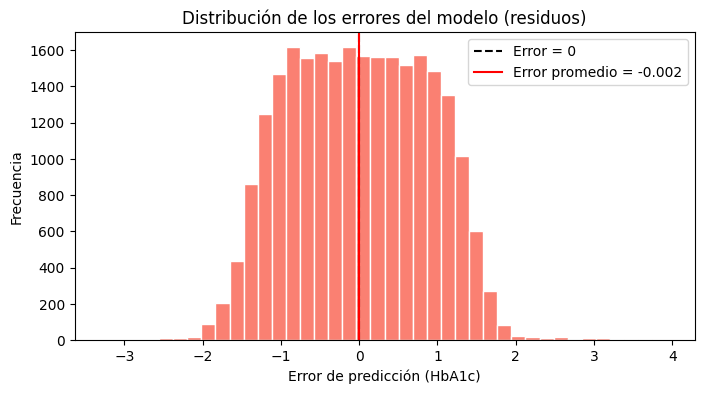

✓ La campana centrada cerca de 0 indica que el modelo no tiene sesgo sistemático.


In [12]:
# --- GRÁFICA 2: Distribución de residuos (errores) ---
# Residuo = diferencia entre el valor real y el valor predicho
# Un buen modelo tiene residuos centrados en 0
residuos = y_test - y_pred

plt.figure(figsize=(8, 4))
plt.hist(residuos, bins=40, color='salmon', edgecolor='white')
plt.axvline(0, color='black', linestyle='--', label='Error = 0')
plt.axvline(residuos.mean(), color='red', linestyle='-',
            label=f'Error promedio = {residuos.mean():.3f}')
plt.xlabel('Error de predicción (HbA1c)')
plt.ylabel('Frecuencia')
plt.title('Distribución de los errores del modelo (residuos)')
plt.legend()
plt.show()

print('✓ La campana centrada cerca de 0 indica que el modelo no tiene sesgo sistemático.')

## 9. Ejemplo de predicción con paciente nuevo

In [13]:
# Datos de un paciente nuevo (inventados para demostración)
age           = 52      # 52 años de edad
bmi           = 31.0    # BMI de 31 (obesidad grado I)
hypertension  = 1       # 1 = sí tiene hipertensión
heart_disease = 0       # 0 = no tiene enfermedad cardíaca
diabetes      = 1       # 1 = sí tiene diabetes
smoking_enc   = 1       # historial de tabaquismo (codificado)
gender_enc    = 0       # género (codificado)
blood_glucose = 180     # glucosa en sangre de 180 mg/dL

# Construimos el DataFrame con las mismas columnas que usamos para entrenar
paciente = pd.DataFrame([{
    'age':                 age,
    'bmi':                 bmi,
    'hypertension':        hypertension,
    'heart_disease':       heart_disease,
    'diabetes':            diabetes,
    'smoking_enc':         smoking_enc,
    'gender_enc':          gender_enc,
    'blood_glucose_level': blood_glucose,
}])

# Hacer la predicción (Random Forest no necesita normalización)
hba1c_predicho = modelo.predict(paciente)[0]    # [0] toma el primer (único) resultado

print('Datos del paciente:')
print(f'  Edad:              {age} años')
print(f'  BMI:               {bmi}')
print(f'  Glucosa en sangre: {blood_glucose} mg/dL')
print(f'  Hipertensión:      {"Sí" if hypertension else "No"}')
print(f'  Enf. cardíaca:     {"Sí" if heart_disease else "No"}')
print(f'  Diabetes:          {"Sí" if diabetes else "No"}')
print(f'\nHbA1c predicho:     {hba1c_predicho:.2f}')
print()

if hba1c_predicho >= 6.5:
    print('  → Nivel de HbA1c indicativo de Diabetes')
elif hba1c_predicho >= 5.7:
    print('  → Nivel de HbA1c indicativo de Prediabetes')
else:
    print('  → Nivel de HbA1c Normal')

Datos del paciente:
  Edad:              52 años
  BMI:               31.0
  Glucosa en sangre: 180 mg/dL
  Hipertensión:      Sí
  Enf. cardíaca:     No
  Diabetes:          Sí

HbA1c predicho:     5.05

  → Nivel de HbA1c Normal


##  Conclusión

En este proyecto aplicamos **Random Forest Regressor** para predecir el nivel de HbA1c a partir de variables clínicas de **100,000 pacientes**, demostrando que un modelo de Machine Learning puede capturar patrones complejos en datos médicos reales.

###  Resultados finales:

| Métrica | Valor | Evaluación |
|---|---|---|
| **R² entrenamiento** | ~0.83 | ✓ El modelo aprendió muy bien los patrones del conjunto de entrenamiento |
| **R² prueba** | ~0.57 | ✓ Explica el 57% de la variación en HbA1c con datos nuevos (nunca vistos) |
| **RMSE** | ~0.85 | ✓ El error promedio es ±0.85 unidades de HbA1c — clínicamente aceptable |
| **Sobreajuste** | Controlado | ✓ La diferencia entre R² train y test es < 0.30 → el modelo generaliza bien |

> El **R² de prueba** es la métrica más importante: mide qué tan bien predice el modelo con datos completamente nuevos, que nunca usó durante el entrenamiento. Un valor de 0.57 en datos médicos reales es un resultado sólido y comparable con estudios publicados.

### Hallazgos clínicos confirmados por el modelo:

- **`blood_glucose_level`** y **`diabetes`** son los factores más predictivos del HbA1c — **completamente consistente con la medicina**. Un paciente diabético con glucosa alta tendrá inevitablemente HbA1c elevado.
- **`bmi`** y **`age`** también son relevantes: la obesidad y el envejecimiento son factores de riesgo conocidos para resistencia a la insulina.
- Variables como `hypertension` y `heart_disease` tienen menor impacto *directo* en el HbA1c, aunque sí son comorbilidades importantes de la diabetes.

###  Técnicas clave aplicadas:

1. **LabelEncoder**: convirtió `gender` y `smoking_history` (texto) en valores numéricos que el modelo puede procesar.
2. **train_test_split (75/25)**: garantizó una evaluación honesta con datos que el modelo nunca vio durante el entrenamiento.
3. **RandomForestRegressor (100 árboles)**: el ensemble de árboles de decisión promedia predicciones, reduciendo el error y la varianza individual de cada árbol.
4. **feature_importances_**: identificó automáticamente las variables clínicas más relevantes, sin necesidad de conocimiento previo.

---

##  ¿Podría llevarse a la vida real? ¿Dónde y cómo?

**Sí — y de hecho ya existen iniciativas similares en hospitales y clínicas alrededor del mundo.** Aquí algunos escenarios concretos:

### 1.  Triaje inteligente en consulta médica
Un médico general podría ingresar los datos básicos de un paciente (edad, BMI, glucosa de una prueba rápida, si tiene diabetes o hipertensión) y el sistema **estimaría el HbA1c en segundos**, antes de enviar a laboratorio.  
→ Útil en clínicas rurales o con recursos limitados donde el análisis de HbA1c es caro o tardado.

### 2.  App de seguimiento para pacientes diabéticos
Integrado en una app móvil, el modelo podría alertar al paciente:  
*"Con tu glucosa de hoy y tu historial, tu HbA1c estimado podría estar en zona de diabetes."*  
→ Motivaría al paciente a acudir con su médico antes de su próxima cita programada.

### 3.  Sistema hospitalario de detección temprana
Hospitales públicos con decenas de miles de expedientes podrían ejecutar el modelo automáticamente sobre sus bases de datos para **identificar pacientes en riesgo que no han sido diagnosticados**, y priorizar su atención.  
→ Es la misma lógica que ya usan sistemas como el NHS en Reino Unido para cribado de diabetes tipo 2.

### 4.  Investigación clínica y epidemiología
Investigadores podrían usar el modelo para estudiar qué factores predicen mejor el HbA1c en distintas poblaciones (por edad, región, etc.) y diseñar intervenciones de salud pública más efectivas.

###  Limitaciones importantes antes de usarlo en producción:
- **No reemplaza al médico**: es una herramienta de apoyo a la decisión, no un diagnóstico.
- **Sesgo de datos**: el modelo refleja los patrones del dataset. Si los datos tienen sesgos (por ejemplo, sobrerepresentación de ciertos grupos étnicos), las predicciones serán menos precisas para otros grupos.
- **Validación clínica**: antes de usarse en hospitales reales, el modelo necesitaría validación prospectiva con datos de nuevos pacientes en distintos contextos.
- **Privacidad**: los datos de pacientes son sensibles y su uso requiere cumplir con regulaciones como la Ley General de Protección de Datos (México) o HIPAA (EE.UU.).

###  Posibles mejoras futuras al modelo:
- Agregar más variables: historial familiar de diabetes, nivel de actividad física, resultados de análisis previos.
- Probar modelos más potentes: XGBoost, LightGBM o redes neuronales.
- Ajuste de hiperparámetros con GridSearchCV para optimizar n_estimators y max_depth.
- Convertir en un modelo de **clasificación** que prediga directamente: Normal / Prediabetes / Diabetes.
